In [2]:
import pandas as pd
import numpy as np
from scipy.stats import t
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
# from sklearn.metrics import hamming_loss
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [ ]:
# Calling Everything

df = pd.read_csv('pressure_washing_cleaned.csv')
lr = LinearRegression()
scaler = StandardScaler()

pl = make_pipeline(scaler, lr)

Data Processing

In [5]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
x = df.drop(columns=['duration', 'gas_cost', 'amount', 'bleach_cost'])

y = df['duration'].reset_index()
y = y.drop(columns='index') # Makes y 2d

In [6]:
# for split testing
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)



Running the model

In [77]:
pl.fit(x_train, y_train)
y_pred = pl.predict(x_test)
mean_squared_error(y_test, y_pred)

0.4150204199933298

Model evaluation making Y hat


Important Metrics

In [ ]:
# coef = pl.named_steps['linearregression'].coef_
# intercept = pl.named_steps['linearregression'].intercept_

coef = 0.00072553
intercept = 1.5907234 # vals were gotten
y_hat = x*coef + intercept

# Making dataframe of the regression line and the mean line
y_hat = pd.DataFrame(y_hat)
mean_line = pd.DataFrame(np.mean(y), index=y.index, columns=['y_mean'])

# Rating our regression line
mean_squared_error(y, mean_line)
mean_squared_error(y, y_hat)

y_table = pd.concat(objs=[y, y_hat, mean_line], axis=1)

y_table.columns = ['y', 'y_regressed', 'y_mean']

# Calculating r^2 score
np.sum((y_table['y'] - y_table['y_regressed'])**2) / np.sum((y_table['y'] - y_table['y_mean'])**2) # 87% r2 score 

Using our model

In [ ]:
# input data
car_sq_feet = 90
num_cars = 9

predict_at_x = car_sq_feet*num_cars # Turns metric into square feet
y_prediction = predict_at_x*coef + intercept # outputs units in hours

In [93]:
MSE = mean_squared_error(y, y_hat) # How good does the line fit Y

p = x.shape[1] + y.shape[1]
n = x.shape[0]
dfyx = n - p # degrees of freedom

SSE = MSE * dfyx # Standard error of Y from Y hat 

x_squared_error = np.var(x)
x_mean = x.mean()['sq_ft_cleaned']
alpha = .025 # 95% CI
critical_value = np.abs(t.ppf(alpha, dfyx))

In [94]:
y_hat_standard_error = MSE * np.sqrt((1/n) + (np.square(predict_at_x-x_mean) / x_squared_error))
interval = y_hat_standard_error * critical_value



In [97]:
# lower limit (many jobs usually take around 2 hours minimum hence the statement)
if y_prediction > 2.5:
    y_prediction = y_prediction - interval
    lower_bound = np.round(y_prediction, 0)
else:
    lower_bound = y_prediction - .5


lower_minutes = np.round(((lower_bound % 1) * 60), decimals=0) 

# upper limit
higher_bound = (y_prediction + interval).round() // 1
higher_minutes = ((higher_bound % 1) * 60).round()

# turning the interval into strings
lower_bound_string = str(np.round(lower_bound, decimals=1)).strip('[].')
lower_minutes_string = str(np.round(lower_minutes, decimals=1)).strip('[].')
higher_bound_string = str(np.round(higher_bound, decimals=1)).strip('[].')
higher_minutes_string = str(np.round(higher_minutes, decimals=1)).strip('[].')


# result
print(f'The job will take between {lower_bound_string} hour(s) and {lower_bound_string} minute(s) and {higher_bound_string} hour(s) and {higher_bound_string} minute(s)')

The job will take between 1.7 hour(s) and 1.7 minute(s) and 3.0 hour(s) and 3.0 minute(s)


Looking at the data

In [79]:
X_line = np.linspace(x.min(), x.max(), 100)

y_line = intercept + coef*X_line
y_mean = np.mean(y)

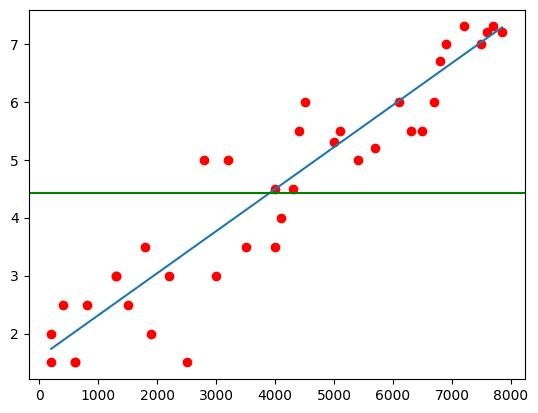

In [80]:
plt.scatter(x, y, color='red') # scatter points
plt.plot(X_line, y_line) # regression line
plt.axhline(y=y_mean, color='green') # mean line

Model Improvement

In [81]:
cross_val_score(X=x, y=y, estimator=pl, scoring='r2', cv=10)

array([ 0.96452463,  0.81690781,  0.19063097,  0.50806587,  0.96750095,
        0.8246253 ,  0.96877828,  0.85269685, -0.98049196,  0.47365021])

In [32]:
new_data = {'sq_ft_cleaned': [800]}
new_frame = pd.DataFrame(data=new_data)

In [21]:
#for cross validation
x = x.reset_index()
x = x.drop(columns='index')

y = y.reset_index()
y = y.drop(columns='index')